<a href="https://colab.research.google.com/github/geraintmelville/moneycraft_project/blob/main/LizMoneyCraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1TCAjS5KtRUrfBW_8tXB_jkTnJPJWNu3J') # Accounts df
df.dtypes

,0
customer_id,int64
month,object
acquisition_channel,object
region,object
age_band,object
account_tier,object
monthly_fee,int64
joined_on_promo,bool


# Feature exploration and Cleaning

## Accounts df

In [4]:
df.shape

(179018, 8)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
customer_id,0
month,0
acquisition_channel,0
region,0
age_band,0
account_tier,0
monthly_fee,0
joined_on_promo,0


### Customer ID

Customer ID has a datatype of int64 (which is desired), so there isn't a need to force it into such a form.

In [7]:
missing_customer_ids = df["customer_id"].isnull().sum()
print(f"Missing Customer IDs: {missing_customer_ids}")

Missing Customer IDs: 0


In [8]:
duplicated_customer_ids = df["customer_id"].duplicated().sum()
print(f"No. duplicated IDs : {duplicated_customer_ids}")

No. duplicated IDs : 163286


How many unique ids are there?

In [9]:
print(f"There are {df["customer_id"].nunique()} unique customers")

There are 15732 unique customers


Duplicate ids exist as customers pay on a monthly basis. To really check for duplicates per month for each customer, one subscription per customer per month

In [10]:
monthly_duplicates = df.duplicated(subset = ["customer_id", "month"]).sum()
print(f"Duplicate Customer IDs within the same month: {monthly_duplicates}")

Duplicate Customer IDs within the same month: 0


In [11]:
customer_id_validity = df[df["customer_id"] <= 0].sum().sum()
print(f"No. customer ids within an unvalid range: {customer_id_validity}")

No. customer ids within an unvalid range: 0


### Month

In [12]:
print(df.month.min())
print(df.month.max())
df["month"].value_counts()

2022-01
2024-12


,count
month,
2024-12,9775
2024-11,9501
2024-10,9147
2024-09,8865
2024-08,8604
2024-07,8319
2024-06,8083
2024-05,7794
2024-04,7480


The months are within a feasible range, there are no abnormalities in the temporal data provided.

In [13]:
# Change month to date
df['month'] = pd.PeriodIndex(df['month'], freq='M')
df['month'].head()

,month
0,2022-01
1,2022-01
2,2022-01
3,2022-01
4,2022-01


### Channel

How many unique channels are there?

In [14]:
print(f"There are {df["acquisition_channel"].nunique()} unique channels")

There are 6 unique channels


In [15]:
print(df["acquisition_channel"].value_counts())

acquisition_channel
Online             43906
Comparison Site    42794
Branch             33277
Referral           25160
Outbound           20298
Broker/IFA         13583
Name: count, dtype: int64


In [16]:
print(f"There are {df["acquisition_channel"].isna().sum()} nulls in the channel columns")

There are 0 nulls in the channel columns


### Region

In [17]:
print(f"There are {df['region'].nunique()} regions")

There are 6 regions


In [18]:
print(df["region"].value_counts())

region
London        42874
North         36890
South East    36613
Midlands      31012
Scotland      17852
Wales & NI    13777
Name: count, dtype: int64


Checking to see if there are any trailing spaces in the region names, they are also already in title form.

In [19]:
print(df["region"].unique().tolist())

['Scotland', 'London', 'South East', 'North', 'Midlands', 'Wales & NI']


### Age Bands

In [20]:
print(f"There are {df["age_band"].nunique()} age bands")

There are 6 age bands


In [21]:
print(df["age_band"].value_counts())

age_band
25-34    45265
35-44    44012
45-54    32397
55-64    22361
18-24    20988
65+      13995
Name: count, dtype: int64


The dataset is heavily comminated by 25-44 year olds

### Account tier

In [22]:
print(f"There are {df["account_tier"].nunique()} account tiers")

There are 4 account tiers


In [23]:
print(df["account_tier"].value_counts())

account_tier
Silver      57256
Gold        54411
Classic     35795
Platinum    31556
Name: count, dtype: int64


In [24]:
print(df["account_tier"].unique().tolist())

['Classic', 'Silver', 'Platinum', 'Gold']


### Monthly fee

In [25]:
print(f"There are {df["monthly_fee"].nunique()} fees")

There are 4 fees


In [26]:
df_fee_table = pd.pivot_table(data = df, values = "monthly_fee", index = "account_tier")
df_fee_table.sort_values("monthly_fee", ascending = True, inplace = True)
df_fee_table["monthly_fee"] = df_fee_table["monthly_fee"].round(2)

In [27]:
df_fee_table.head()

,monthly_fee
account_tier,
Classic,0.00
Silver,8.82
Gold,16.03
Platinum,25.75


The monthly fees are irregularly priced

### Joined on a promotional basis

In [28]:
print(df["joined_on_promo"].nunique())

2


In [29]:
print(df["joined_on_promo"].value_counts())

joined_on_promo
False    115271
True      63747
Name: count, dtype: int64


## Closure df

In [30]:
df_closure = pd.read_csv('https://drive.google.com/uc?export=download&id=13ITGgf4LkmWRlCjWS-xEU4l8Ih1SIOKq') # Reason df
df_closure.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


In [31]:
df_closure.duplicated().sum()

np.int64(0)

In [32]:
df_marketing = pd.read_csv('https://drive.google.com/uc?export=download&id=1m6tSVLT6IkExQ_xDnwBIUoFkgboDpyaL') # Marketing df
df_marketing.head(20)

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0
5,2022-01,Referral,1872.0
6,2022-02,Branch,7882.0
7,2022-02,Broker/IFA,1989.0
8,2022-02,Comparison Site,3266.0
9,2022-02,Online,4231.0


## Sort row

In [33]:
df = df.sort_values(['customer_id', 'month'])
df.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False


## Group by customer_id

In [34]:
# This will be the customer tenure
df.groupby('customer_id')['month'].count().head()

,month
customer_id,
1,6
2,36
3,36
4,36
5,10


### Save and build the columns

In [35]:
from typing import AsyncGenerator
grouped = df.groupby('customer_id')

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()
last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
# ever_paid = grouped['monthly_fee' > 0]


### Single Customer view


In [36]:
scv = pd.DataFrame({
    'signup_month': signup_month,
   'last_active': last_active,
    'tenure_months': tenure_months,
    'channel': channel,
    'age_band': age_band,
    'region': region,
    'first_plan': first_plan,
    'last_plan': last_plan,
    'total_revenue': total_revenue,
    'max_paid': max_paid
})

scv['ever_paid'] = max_paid > 0
scv.head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid
customer_id,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True


In [37]:
from typing_extensions import final
# Add churned flag
final_month = df['month'].max()   # Last month in data
scv['churned'] = scv['last_active'] < final_month
scv.head()
# scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned
customer_id,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True


***CALCULATE: the churn rate***

In [38]:
scv['churned'].mean().round(2)

np.float64(0.38)

*Don't forget we need to merge the tables*

In [39]:
# Merging tables - main table with closure data
df_merged = pd.merge(scv, df_closure, on='customer_id', how='left')
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [40]:
# Reasons why people left and how it could help with our recommendations
df_merged['reason_code'].value_counts()

,count
reason_code,
Fees too high,1268
Poor service,887
Unknown,635
Switched provider,623
Unhappy with perks,254
Moved abroad,210
Bereavement,146


***Find out when and why most customers left***
*Then look into changing NaN to 'No reason given'*
*Create a rentention curve*

**Channel bar chart**
**Bool and category** Yes or No

In [41]:
# Retention curve
max_t = int(scv['tenure_months'].max())
# max_time = max_t + 1

# For each mont
retention = [(scv['tenure_months']> t).mean() for t in range(max_t)]
retention[:5]

[np.float64(1.0),
 np.float64(0.9057971014492754),
 np.float64(0.8263412153572337),
 np.float64(0.7631578947368421),
 np.float64(0.7072209509280447)]

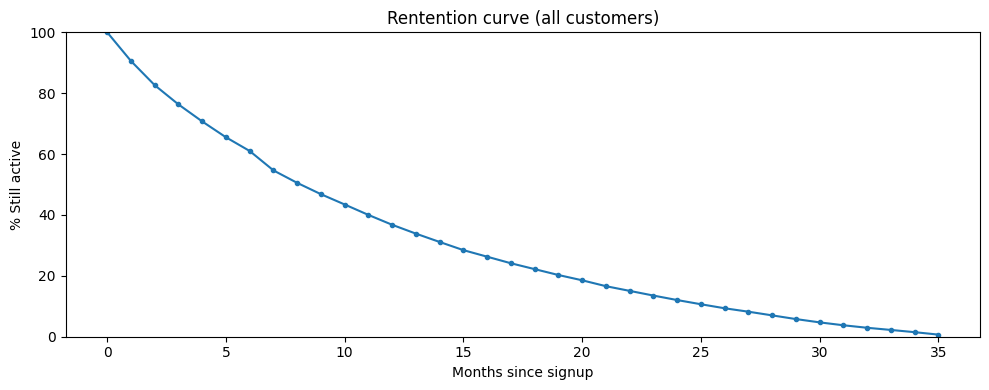

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(range(max_t), [r * 100 for r in retention], marker='.')
plt.title('Rentention curve (all customers)')
plt.xlabel('Months since signup')
plt.ylabel('% Still active')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cohort based on channel and subscriptions

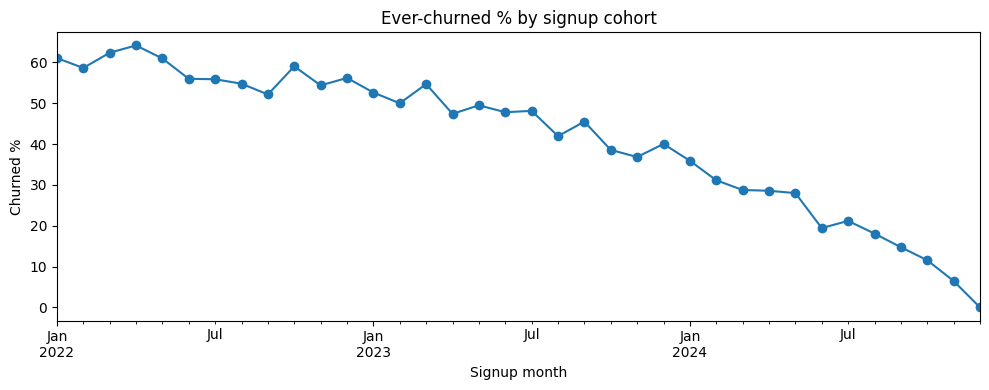

In [43]:
# Cohorts
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100

plt.figure(figsize=(10, 4))
cohort_churn.plot(marker='o')
plt.title('Ever-churned % by signup cohort')
plt.xlabel('Signup month')
plt.ylabel('Churned %')
plt.tight_layout()
plt.show()

In [44]:
df_merged.to_csv("merged_closure.csv", index=True)

In [45]:
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [46]:
df_merged.isna().sum()

,0
customer_id,0
signup_month,0
last_active,0
tenure_months,0
channel,0
age_band,0
region,0
first_plan,0
last_plan,0
total_revenue,0


In [47]:
df_merged_chruned = df_merged.dropna()

**LIFETIME VALUE (LTV)**

In [48]:
scv.groupby('first_plan')['total_revenue'].mean().round(2)

,total_revenue
first_plan,
Classic,26.54
Gold,226.38
Platinum,326.41
Silver,115.49


In [ ]:
plt.barh()

ARPU - Total money from paying customer's divided by their total active months

In [49]:
pay = scv[scv['ever_paid']]
arpu = pay['total_revenue'].sum() / pay['tenure_months'].sum()
print(f'ARPU: £{arpu:,.0f}')

ARPU: £15


In [50]:
paying = df[df['joined_on_promo'] == False].copy()

paying['next_month'] = paying.groupby('customer_id')['month'].shift(-1)   # peek at next month
paying['is_last_row'] = paying['next_month'].isna()
paying['churned_here'] = paying['is_last_row'] & (paying['month'] < final_month)
paying[['customer_id', 'month', 'next_month', 'churned_here']].head()

,customer_id,month,next_month,churned_here
0,1,2022-01,2022-02,False
280,1,2022-02,2022-03,False
840,1,2022-03,2022-04,False
1664,1,2022-04,2022-05,False
2750,1,2022-05,2022-06,False


In [51]:
monthly_churn = paying['churned_here'].mean()
print(f'Monthly churn rate: {monthly_churn:.1%}')

ltv = arpu / monthly_churn
print(f'Naive LTV estimates: £{ltv:,.0f}')

Monthly churn rate: 2.8%
Naive LTV estimates: £523


Raw Churn by channel

In [52]:
raw = (paying.groupby('acquisition_channel')['churned_here'].mean() * 100).round(2)
raw.sort_values(ascending=False)

,churned_here
acquisition_channel,
Comparison Site,5.00
Outbound,4.32
Online,3.24
Branch,1.80
Referral,1.75
Broker/IFA,1.52


Churn by channel within each plan

In [53]:
within = (paying.groupby(['account_tier', 'acquisition_channel'])['churned_here'].mean() * 100).round(2)
within.unstack()

acquisition_channel,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
account_tier,,,,,,
Classic,4.99,4.74,7.86,6.08,6.95,4.56
Gold,1.41,1.37,2.28,2.03,2.42,1.31
Platinum,0.89,0.73,1.02,1.24,2.05,0.68
Silver,2.32,3.02,4.20,3.22,4.19,2.52


The hidden cause: plan mix

In [54]:
# One row per customer
first_rows = df.drop_duplicates('customer_id')
plan_mix = pd.crosstab(first_rows['account_tier'], first_rows['acquisition_channel'], normalize='index') * 100
plan_mix

acquisition_channel,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
account_tier,,,,,,
Classic,7.953568,0.988822,44.862425,25.881341,14.982803,5.331040
Gold,24.499863,11.071526,15.209646,21.540148,10.167169,17.511647
Platinum,28.792057,18.532819,6.012135,20.904578,5.846663,19.911748
Silver,12.370951,3.435386,32.627269,26.379494,14.026344,11.160555


**Track 3: Churn Dynamic & Retention Analysis (The 'Leaky Bucket' Assessment)**

Join the account closure database with customer profiles to compute average tenure (months active) across channels and tiers.


In [134]:
# Finding the average tenure (months active) across the various channels and packages (account tiers).
avg_tenure_per_channel = df_merged_chruned.groupby(['channel', 'first_plan'])['tenure_months'].mean().round(2)
display(avg_tenure_per_channel)

channel          first_plan
Branch           Classic        8.86
                 Gold           8.21
                 Platinum       9.91
                 Silver         9.07
Broker/IFA       Classic        7.33
                 Gold           8.61
                 Platinum      10.45
                 Silver         8.32
Comparison Site  Classic        6.35
                 Gold           9.01
                 Platinum      12.00
                 Silver         7.97
Online           Classic        7.41
                 Gold           9.93
                 Platinum      10.69
                 Silver         9.66
Outbound         Classic        6.91
                 Gold          10.23
                 Platinum       7.88
                 Silver         9.63
Referral         Classic        8.08
                 Gold          10.00
                 Platinum      10.57
                 Silver         8.91
Name: tenure_months, dtype: float64

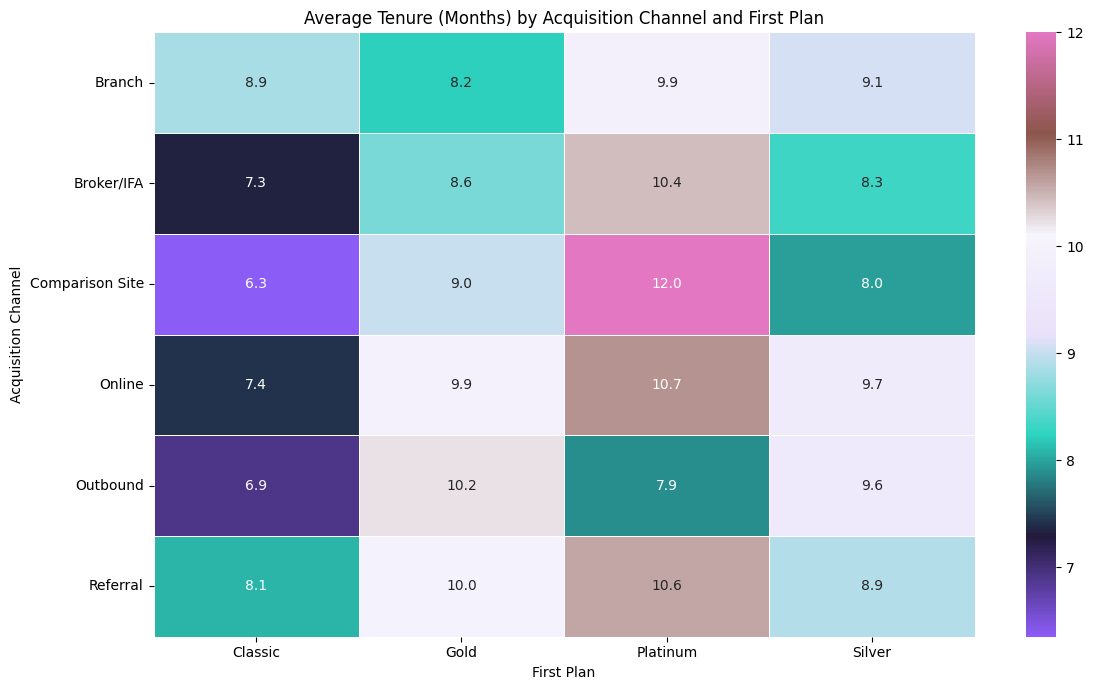

In [135]:
# Finding the average tenure (months active) across the various channels and packages (account tiers).
avg_tenure_per_channel = df_merged_chruned.groupby(['channel', 'first_plan'])['tenure_months'].mean().round(2)

# Reshape the data for a heatmap
avg_tenure_pivot = avg_tenure_per_channel.unstack()

# Define your custom colors (reusing the list from previous interaction)
custom_colors = ['#8B5CF6', '#211A3B', '#2DD4BF', '#E9E1FA', '#F6F4FC', '#8c564b', '#e377c2']

# Create a custom colormap from the list of colors
from matplotlib.colors import LinearSegmentedColormap
cmap_custom = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)

plt.figure(figsize=(12, 7))
sns.heatmap(avg_tenure_pivot, annot=True, fmt=".1f", cmap=cmap_custom, linewidths=.5)
plt.title('Average Tenure (Months) by Acquisition Channel and First Plan')
plt.xlabel('First Plan')
plt.ylabel('Acquisition Channel')
plt.tight_layout()
plt.show()

Analyze the programmatic distribution of reason codes (e.g., 'Switched provider', 'Fees too high') segmented by channel.

In [56]:
reason_code_distribution = df_merged_chruned.groupby(['channel', 'reason_code']).size().unstack(fill_value=0)
reason_code_distribution_percent = reason_code_distribution.apply(lambda x: (x / x.sum()) * 100, axis=1).round(2)
display(reason_code_distribution_percent)

reason_code,Bereavement,Fees too high,Moved abroad,Poor service,Switched provider,Unhappy with perks,Unknown
channel,,,,,,,
Branch,4.17,14.58,6.48,30.09,13.43,14.12,17.13
Broker/IFA,3.45,11.03,6.90,27.59,17.24,15.17,18.62
Comparison Site,2.89,46.82,3.73,15.61,17.47,2.18,11.30
Online,3.48,24.43,6.55,25.62,14.30,6.65,18.97
Outbound,4.66,26.42,4.84,24.53,14.16,5.01,20.38
Referral,5.28,20.13,6.60,24.42,13.86,13.53,16.17


<Figure size 1200x700 with 0 Axes>

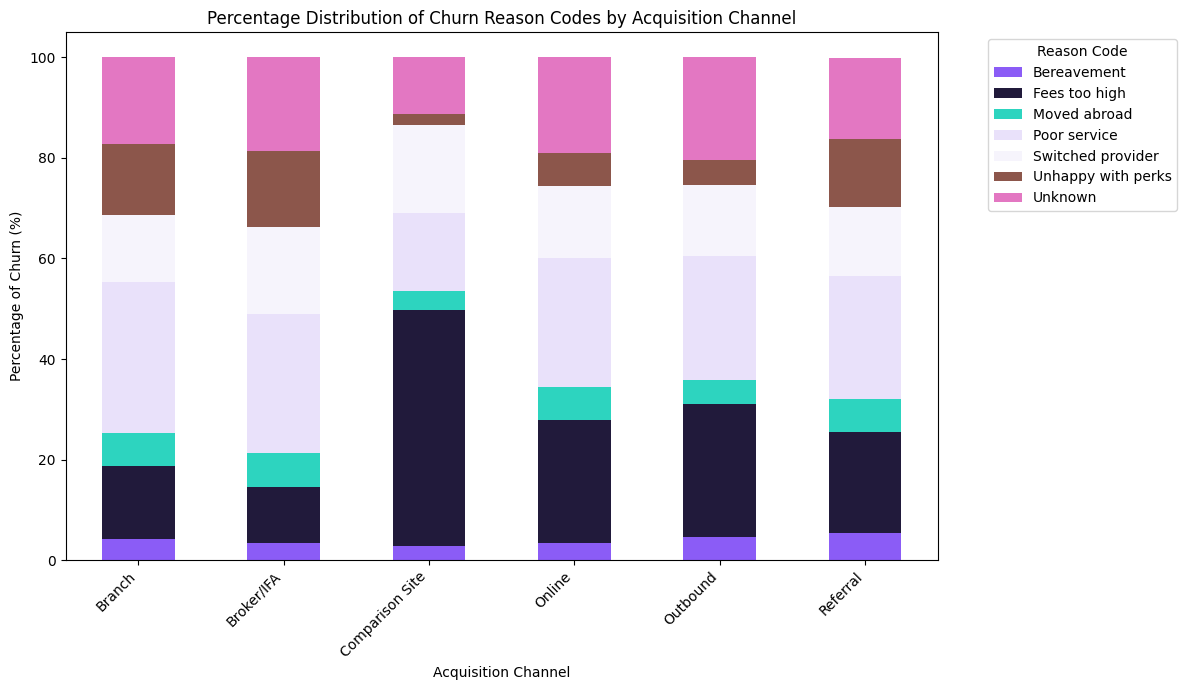

In [130]:
plt.figure(figsize=(12, 7))
# Define your custom colors here
custom_colors = ['#8B5CF6', '#211A3B', '#2DD4BF', '#E9E1FA', '#F6F4FC', '#8c564b', '#e377c2']
reason_code_distribution_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
plt.title('Percentage Distribution of Churn Reason Codes by Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Percentage of Churn (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reason Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

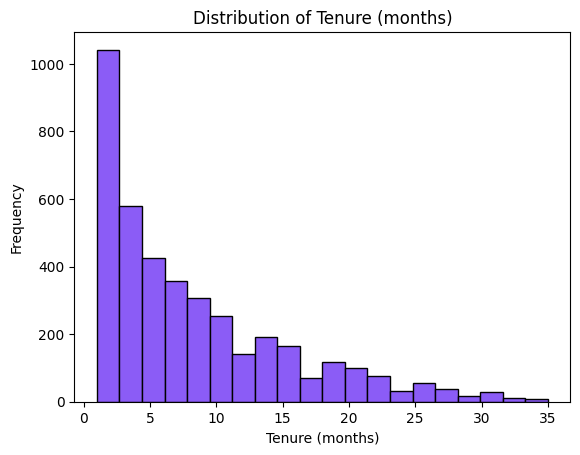

In [67]:
# Customers who have churned, the months they churned and the freq.
plt.hist(df_merged_chruned['tenure_months'], bins=20, edgecolor='black', color='#8B5CF6')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.title('Distribution of Tenure (months)')
plt.show()

Develop survival-rate charts indicating the specific operational intervals where newly acquired segments are most prone to attrition.

### Survival Rate by Acquisition Channel

In [132]:
# Calculate the customer retention rate over time, segmented by the acquisition channel.

# Get the maximum tenure observed in the data - longest period a customer has been active in months
max_tenure = scv['tenure_months'].max()

# Initialize an empty DataFrame to store retention rates by channel - months since signup from 1 to the
# max (plus one because we are using 'range')
retention_by_channel = pd.DataFrame(index=range(1, max_tenure + 1))

# Loop through each channel to create a group containing all customers acquired through that channel
for channel_name, group in scv.groupby('channel'):
    cohort_size = len(group)  # The number of customers in the current channel
    if cohort_size == 0:
        retention_by_channel[channel_name] = np.nan
        continue

    channel_retention = []
    for t in range(1, max_tenure + 1):
        num_retained = (group['tenure_months'] >= t).sum()
        channel_retention.append((num_retained / cohort_size) * 100)
    retention_by_channel[channel_name] = channel_retention

display(retention_by_channel.head().round(2))

,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
1,100.00,100.00,100.00,100.00,100.00,100.00
2,92.62,95.10,87.78,91.43,88.43,92.85
3,86.66,89.99,77.73,83.82,79.87,85.92
4,81.78,84.98,70.00,77.77,72.48,81.01
5,76.30,80.49,63.53,72.66,65.55,77.28


Sharpest drop (calculate the monthly drop for each channel)

In [66]:
# Calculate the monthly drop in retention for each channel
retention_drops = retention_by_channel.diff(periods=-1, axis=0) * -1 # Difference with next month, then make positive for drops

# Or, to show the actual percentage drop from one month to the next:
monthly_retention_change = retention_by_channel.diff() # Difference from previous month

# Find the month with the sharpest drop for each channel
# We're looking for the largest negative change, so min() on diff()
sharpest_drops_month_and_value = monthly_retention_change.min()

print("Monthly Percentage Change in Retention (Negative values indicate a drop):")
display(monthly_retention_change.head().round(2))

print("\nSharpest Drop (Largest negative change) and the month it occurred:")
for channel in monthly_retention_change.columns:
    min_drop = monthly_retention_change[channel].min()
    month_of_sharpest_drop = monthly_retention_change[channel].idxmin()
    print(f"  {channel}: Month {month_of_sharpest_drop}, Drop: {min_drop:.2f}%")

Monthly Percentage Change in Retention (Negative values indicate a drop):


,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
1,NaN,NaN,NaN,NaN,NaN,NaN
2,-7.38,-4.90,-12.22,-8.57,-11.57,-7.15
3,-5.97,-5.11,-10.06,-7.61,-8.56,-6.93
4,-4.88,-5.01,-7.72,-6.05,-7.39,-4.91
5,-5.48,-4.49,-6.48,-5.12,-6.93,-3.73



Sharpest Drop (Largest negative change) and the month it occurred:
  Branch: Month 2, Drop: -7.38%
  Broker/IFA: Month 6, Drop: -5.52%
  Comparison Site: Month 2, Drop: -12.22%
  Online: Month 2, Drop: -8.57%
  Outbound: Month 2, Drop: -11.57%
  Referral: Month 2, Drop: -7.15%


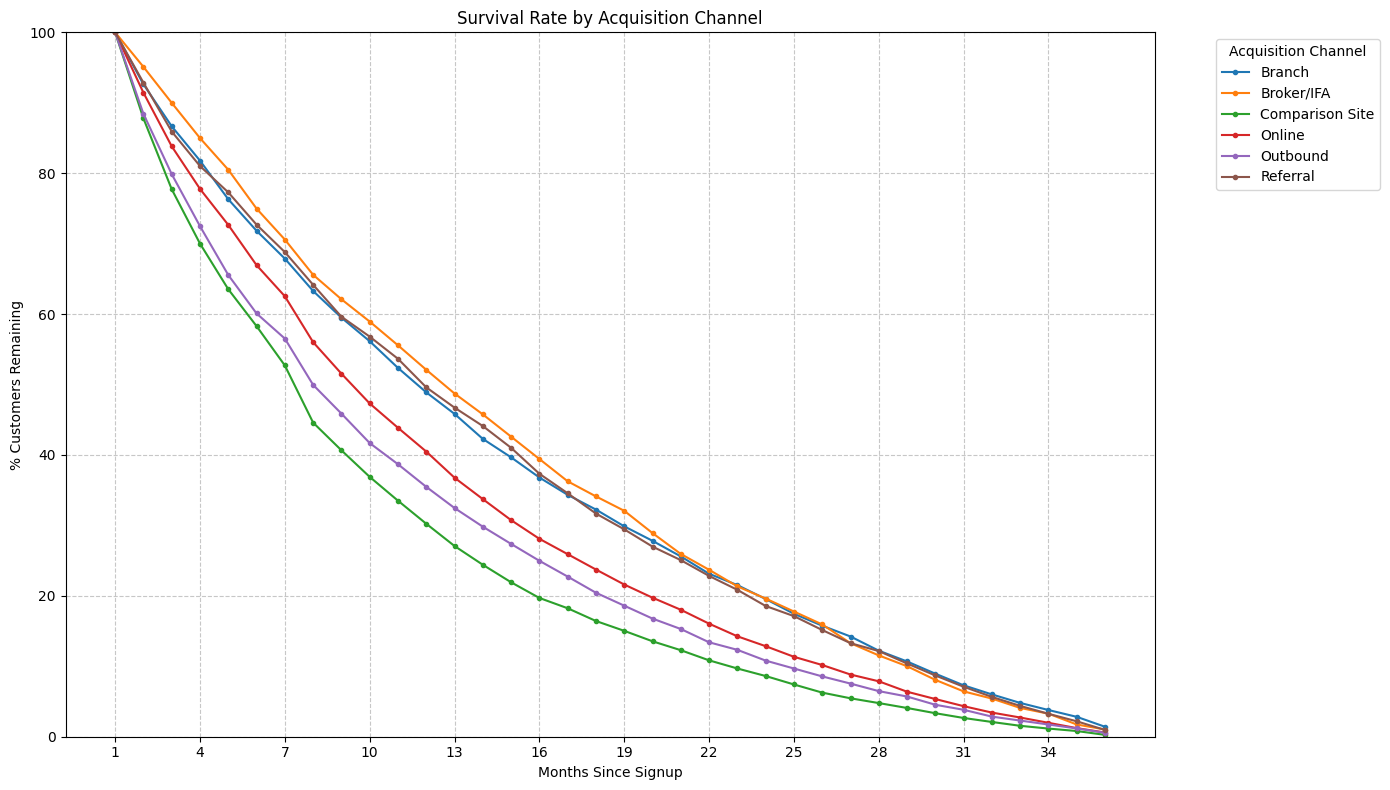

In [60]:
plt.figure(figsize=(14, 8))
for column in retention_by_channel.columns:
    plt.plot(retention_by_channel.index, retention_by_channel[column], label=column, marker='.')

plt.title('Survival Rate by Acquisition Channel')
plt.xlabel('Months Since Signup')
plt.ylabel('% Customers Remaining')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Acquisition Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.xticks(np.arange(1, max_tenure + 1, 3)) # Show x-ticks every 3 months for readability
plt.tight_layout()
plt.show()

### Survival Rate by Account Tier (First Plan)

In [61]:
# Initialize an empty DataFrame to store retention rates by account tier
retention_by_tier = pd.DataFrame(index=range(1, max_tenure + 1))

# Iterate through each unique account tier
for tier_name, group in scv.groupby('first_plan'):
    cohort_size = len(group)
    if cohort_size == 0:
        retention_by_tier[tier_name] = np.nan
        continue

    tier_retention = []
    for t in range(1, max_tenure + 1):
        num_retained = (group['tenure_months'] >= t).sum()
        tier_retention.append((num_retained / cohort_size) * 100)
    retention_by_tier[tier_name] = tier_retention

display(retention_by_tier.head().round(2))

,Classic,Gold,Platinum,Silver
1,100.00,100.00,100.00,100.00
2,86.41,93.45,93.55,91.21
3,75.69,87.53,88.03,83.46
4,67.50,82.38,83.01,77.52
5,60.51,77.83,78.76,71.97


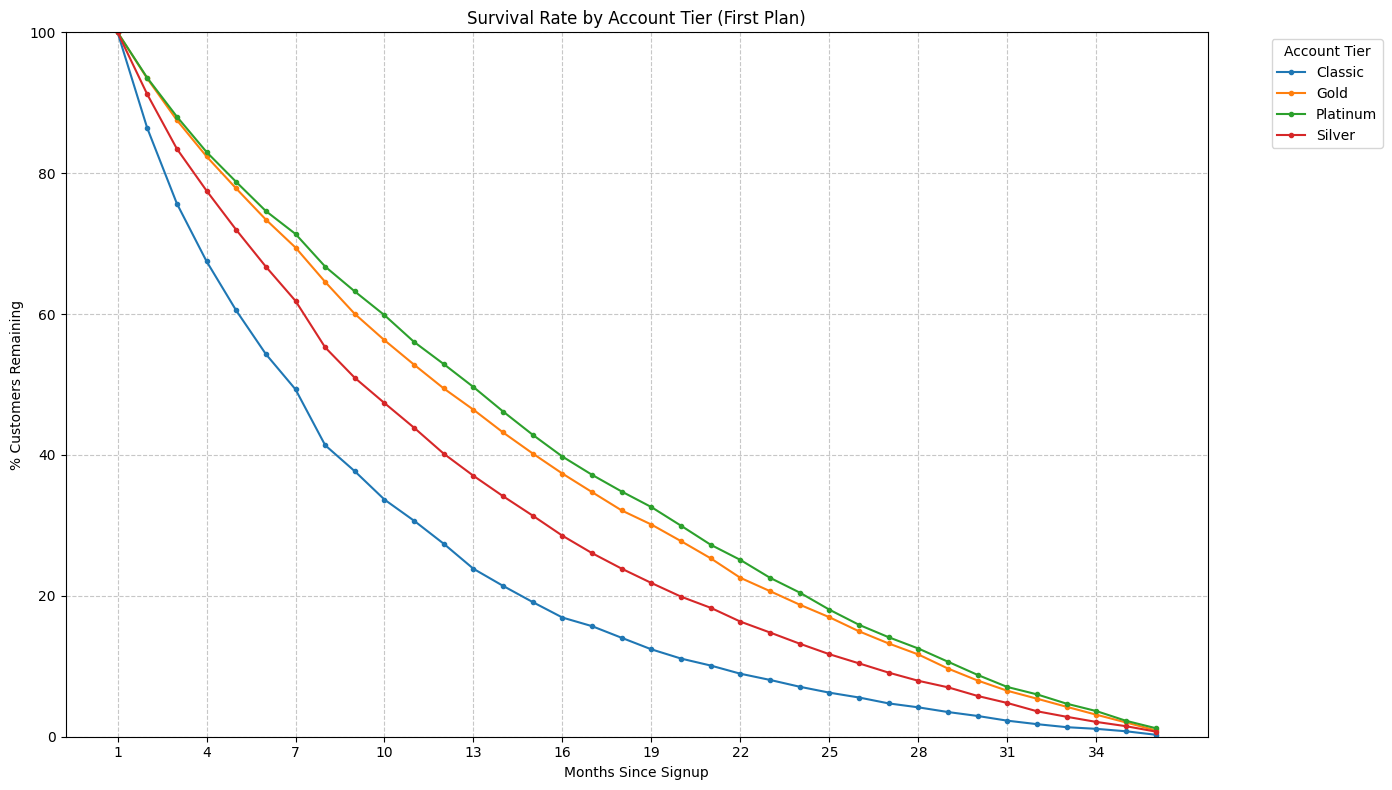

In [62]:
plt.figure(figsize=(14, 8))
for column in retention_by_tier.columns:
    plt.plot(retention_by_tier.index, retention_by_tier[column], label=column, marker='.')

plt.title('Survival Rate by Account Tier (First Plan)')
plt.xlabel('Months Since Signup')
plt.ylabel('% Customers Remaining')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Account Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.xticks(np.arange(1, max_tenure + 1, 3)) # Show x-ticks every 3 months for readability
plt.tight_layout()
plt.show()